In [2]:
from pathlib import Path

# Locate dataset in the local repository root
data_file = Path('dataset.csv')
if data_file.exists():
    print(f"Dataset found: {data_file.resolve()}")
else:
    print("Dataset missing from current directory.")

Dataset found: C:\Users\vshar\OneDrive\Desktop\dataset.csv


In [14]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Reading the Dataset

In [15]:
import pandas as pd

# Load the dataset from the local directory
df = pd.read_csv("dataset.csv")
df

,PatientID,Age,Gender,State,Tenure_Months,Specialty,Insurance_Type,Visits_Last_Year,Missed_Appointments,Days_Since_Last_Visit,...,Overall_Satisfaction,Wait_Time_Satisfaction,Staff_Satisfaction,Provider_Rating,Avg_Out_Of_Pocket_Cost,Billing_Issues,Portal_Usage,Referrals_Made,Distance_To_Facility_Miles,Churned
0,C20000,41,Female,PA,62,Pediatrics,Medicaid,1,0,564,...,3.5,4.9,3.8,4.2,306,0,0,3,21.4,1
1,C20001,43,Female,GA,44,Internal Medicine,Self-Pay,7,4,254,...,2.6,3.1,4.7,4.3,1851,0,0,0,47.6,1
2,C20002,21,Male,MI,120,Internal Medicine,Medicaid,15,5,89,...,1.6,4.4,2.1,4.7,391,0,0,2,7.1,0
3,C20003,65,Male,FL,118,General Practice,Private,10,3,135,...,2.6,4.3,4.3,4.9,808,0,0,0,11.6,1
4,C20004,18,Female,CA,70,Cardiology,Medicaid,5,4,696,...,2.2,4.0,4.1,4.4,866,0,0,0,10.3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,C21995,31,Male,NC,78,Internal Medicine,Medicare,8,2,180,...,3.9,1.8,2.4,2.9,268,0,1,0,42.6,1
1996,C21996,45,Female,GA,69,Internal Medicine,Private,6,4,352,...,4.2,2.8,3.5,4.6,1257,1,0,3,15.4,1
1997,C21997,37,Male,NC,91,Family Medicine,Medicare,9,4,494,...,3.9,2.7,3.0,2.7,50,0,1,3,2.6,0
1998,C21998,69,Female,NY,5,Internal Medicine,Private,3,0,315,...,1.7,3.2,3.6,4.2,848,0,0,1,38.8,1


Exploratory Data Analysis

In [21]:
print(df.columns)
df.shape

Index(['PatientID', 'Age', 'Gender', 'State', 'Tenure_Months', 'Specialty',
       'Insurance_Type', 'Visits_Last_Year', 'Missed_Appointments',
       'Days_Since_Last_Visit', 'Last_Interaction_Date',
       'Overall_Satisfaction', 'Wait_Time_Satisfaction', 'Staff_Satisfaction',
       'Provider_Rating', 'Avg_Out_Of_Pocket_Cost', 'Billing_Issues',
       'Portal_Usage', 'Referrals_Made', 'Distance_To_Facility_Miles',
       'Churned'],
      dtype='object')


(2000, 21)

In [22]:
df.columns=df.columns.str.lower()
df.columns

Index(['patientid', 'age', 'gender', 'state', 'tenure_months', 'specialty',
       'insurance_type', 'visits_last_year', 'missed_appointments',
       'days_since_last_visit', 'last_interaction_date',
       'overall_satisfaction', 'wait_time_satisfaction', 'staff_satisfaction',
       'provider_rating', 'avg_out_of_pocket_cost', 'billing_issues',
       'portal_usage', 'referrals_made', 'distance_to_facility_miles',
       'churned'],
      dtype='object')

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   PatientID                   2000 non-null   object 
 1   Age                         2000 non-null   int64  
 2   Gender                      2000 non-null   object 
 3   State                       2000 non-null   object 
 4   Tenure_Months               2000 non-null   int64  
 5   Specialty                   2000 non-null   object 
 6   Insurance_Type              2000 non-null   object 
 7   Visits_Last_Year            2000 non-null   int64  
 8   Missed_Appointments         2000 non-null   int64  
 9   Days_Since_Last_Visit       2000 non-null   int64  
 10  Last_Interaction_Date       2000 non-null   object 
 11  Overall_Satisfaction        2000 non-null   float64
 12  Wait_Time_Satisfaction      2000 non-null   float64
 13  Staff_Satisfaction          2000 

In [8]:
df['insurance_type'].value_counts()

insurance_type
Self-Pay    523
Medicare    516
Private     483
Medicaid    478
Name: count, dtype: int64

In [9]:
df['specialty'].value_counts()

specialty
General Practice     302
Family Medicine      289
Orthopedics          289
Neurology            286
Pediatrics           284
Internal Medicine    277
Cardiology           273
Name: count, dtype: int64

In [10]:
df.head()

,patientid,age,gender,state,tenure_months,specialty,insurance_type,visits_last_year,missed_appointments,days_since_last_visit,...,overall_satisfaction,wait_time_satisfaction,staff_satisfaction,provider_rating,avg_out_of_pocket_cost,billing_issues,portal_usage,referrals_made,distance_to_facility_miles,churned
0,C20000,41,Female,PA,62,Pediatrics,Medicaid,1,0,564,...,3.5,4.9,3.8,4.2,306,0,0,3,21.4,1
1,C20001,43,Female,GA,44,Internal Medicine,Self-Pay,7,4,254,...,2.6,3.1,4.7,4.3,1851,0,0,0,47.6,1
2,C20002,21,Male,MI,120,Internal Medicine,Medicaid,15,5,89,...,1.6,4.4,2.1,4.7,391,0,0,2,7.1,0
3,C20003,65,Male,FL,118,General Practice,Private,10,3,135,...,2.6,4.3,4.3,4.9,808,0,0,0,11.6,1
4,C20004,18,Female,CA,70,Cardiology,Medicaid,5,4,696,...,2.2,4.0,4.1,4.4,866,0,0,0,10.3,1


In [11]:
df.describe()

,age,tenure_months,visits_last_year,missed_appointments,days_since_last_visit,overall_satisfaction,wait_time_satisfaction,staff_satisfaction,provider_rating,avg_out_of_pocket_cost,billing_issues,portal_usage,referrals_made,distance_to_facility_miles,churned
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,52.856500,60.733500,7.614000,2.028000,366.130000,3.255000,3.289900,3.525900,3.736100,836.544000,0.078500,0.206000,1.483500,25.167400,0.683500
std,15.836487,35.111293,4.672143,1.699312,212.890277,1.008595,1.009062,0.871613,0.733748,589.031896,0.269024,0.404532,1.100151,13.948284,0.465227
min,18.000000,1.000000,0.000000,0.000000,1.000000,1.500000,1.500000,2.000000,2.500000,20.000000,0.000000,0.000000,0.000000,0.500000,0.000000
25%,41.000000,30.000000,4.000000,0.000000,180.000000,2.400000,2.400000,2.775000,3.100000,326.000000,0.000000,0.000000,1.000000,12.800000,0.000000
50%,54.000000,60.000000,8.000000,2.000000,363.000000,3.200000,3.300000,3.500000,3.800000,716.000000,0.000000,0.000000,1.000000,25.000000,1.000000
75%,65.000000,92.250000,12.000000,3.000000,550.250000,4.100000,4.100000,4.300000,4.400000,1368.250000,0.000000,0.000000,2.000000,37.200000,1.000000
max,90.000000,120.000000,15.000000,5.000000,730.000000,5.000000,5.000000,5.000000,5.000000,1999.000000,1.000000,1.000000,3.000000,50.000000,1.000000


Check Data Types

In [23]:
df['last_interaction_date'].head()

0    2024-07-05
1    2025-05-11
2    2025-10-23
3    2025-09-07
4    2024-02-24
Name: last_interaction_date, dtype: object

In [24]:
df['last_interaction_date']=pd.to_datetime(df['last_interaction_date'])

In [25]:
df.dtypes

patientid                             object
age                                    int64
gender                                object
state                                 object
tenure_months                          int64
specialty                             object
insurance_type                        object
visits_last_year                       int64
missed_appointments                    int64
days_since_last_visit                  int64
last_interaction_date         datetime64[ns]
overall_satisfaction                 float64
wait_time_satisfaction               float64
staff_satisfaction                   float64
provider_rating                      float64
avg_out_of_pocket_cost                 int64
billing_issues                         int64
portal_usage                           int64
referrals_made                         int64
distance_to_facility_miles           float64
churned                                int64
dtype: object

Remove Nulls and Dupes

In [26]:
df.isna().sum()

patientid                     0
age                           0
gender                        0
state                         0
tenure_months                 0
specialty                     0
insurance_type                0
visits_last_year              0
missed_appointments           0
days_since_last_visit         0
last_interaction_date         0
overall_satisfaction          0
wait_time_satisfaction        0
staff_satisfaction            0
provider_rating               0
avg_out_of_pocket_cost        0
billing_issues                0
portal_usage                  0
referrals_made                0
distance_to_facility_miles    0
churned                       0
dtype: int64

In [27]:
df.duplicated().sum()

np.int64(0)

In [28]:
df['insurance_type'].unique()

array(['Medicaid', 'Self-Pay', 'Private', 'Medicare'], dtype=object)

In [29]:
df.head()

,patientid,age,gender,state,tenure_months,specialty,insurance_type,visits_last_year,missed_appointments,days_since_last_visit,...,overall_satisfaction,wait_time_satisfaction,staff_satisfaction,provider_rating,avg_out_of_pocket_cost,billing_issues,portal_usage,referrals_made,distance_to_facility_miles,churned
0,C20000,41,Female,PA,62,Pediatrics,Medicaid,1,0,564,...,3.5,4.9,3.8,4.2,306,0,0,3,21.4,1
1,C20001,43,Female,GA,44,Internal Medicine,Self-Pay,7,4,254,...,2.6,3.1,4.7,4.3,1851,0,0,0,47.6,1
2,C20002,21,Male,MI,120,Internal Medicine,Medicaid,15,5,89,...,1.6,4.4,2.1,4.7,391,0,0,2,7.1,0
3,C20003,65,Male,FL,118,General Practice,Private,10,3,135,...,2.6,4.3,4.3,4.9,808,0,0,0,11.6,1
4,C20004,18,Female,CA,70,Cardiology,Medicaid,5,4,696,...,2.2,4.0,4.1,4.4,866,0,0,0,10.3,1


Outliear Analysis

In [30]:
def outliers(df,column):
    Q1=df[column].quantile(0.25)
    Q3=df[column].quantile(0.75)
    IQR=Q3-Q1
    indeces_outlier=df[(df[column]< (Q1 - 1.5*IQR)) | (df[column]> (Q3 + 1.5 * IQR))].index
    return indeces_outlier

In [31]:
print(outliers (df ,'tenure_months' ))
print(outliers (df ,'days_since_last_visit' ))
print(outliers (df ,'avg_out_of_pocket_cost' ))
outliers (df ,'distance_to_facility_miles' )

Index([], dtype='int64')
Index([], dtype='int64')
Index([], dtype='int64')


Index([], dtype='int64')

Visualizing Data

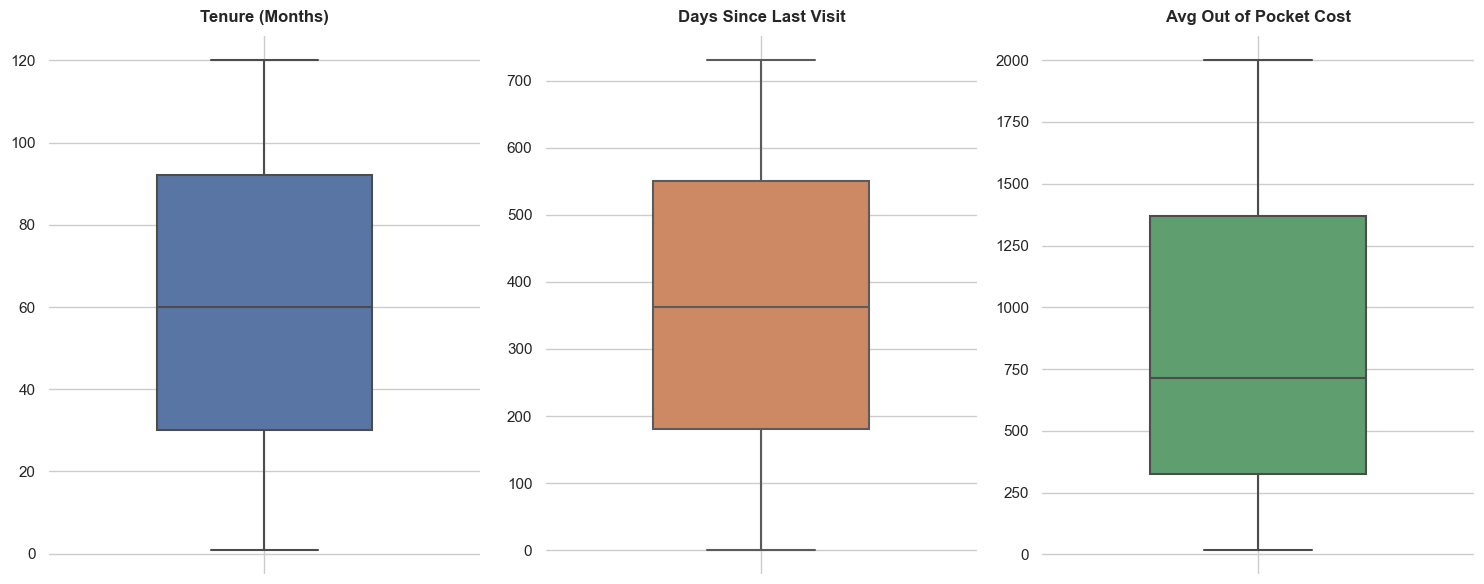

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean aesthetic
sns.set_theme(style="whitegrid", palette="muted")

fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=False)

# Custom plot parameters to make them look sharp
props = dict(fliersize=4, width=0.5, linewidth=1.5)

sns.boxplot(data=df, y='tenure_months', ax=axes[0], color='#4c72b0', **props)
axes[0].set_title('Tenure (Months)', fontsize=12, fontweight='semibold', pad=10)
axes[0].set_ylabel('')

sns.boxplot(data=df, y='days_since_last_visit', ax=axes[1], color='#dd8452', **props)
axes[1].set_title('Days Since Last Visit', fontsize=12, fontweight='semibold', pad=10)
axes[1].set_ylabel('')

sns.boxplot(data=df, y='avg_out_of_pocket_cost', ax=axes[2], color='#55a868', **props)
axes[2].set_title('Avg Out of Pocket Cost', fontsize=12, fontweight='semibold', pad=10)
axes[2].set_ylabel('')

# Clean up the spines/borders
for ax in axes:
    sns.despine(ax=ax, left=True, bottom=True)
    ax.grid(axis='x') # Remove vertical lines, keep horizontal grid

plt.tight_layout()
plt.show()

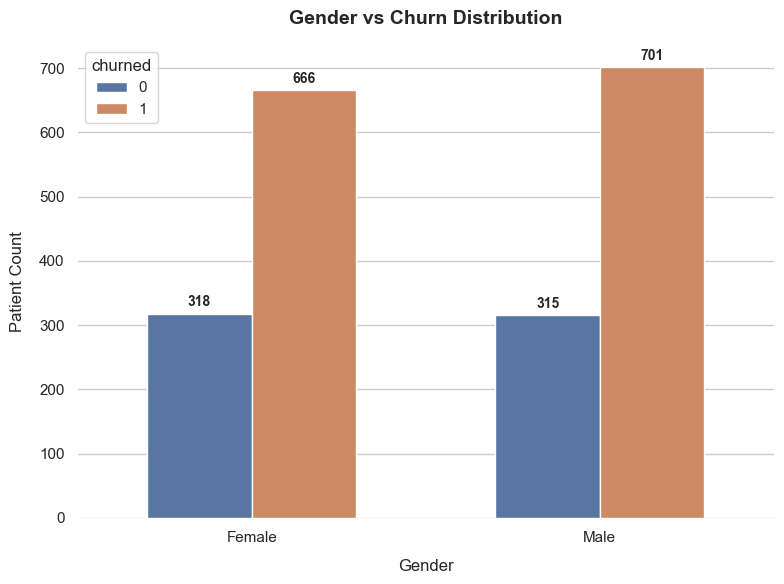

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Clean look and muted colors
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(8, 6))

# Better palette and narrower bars
ax = sns.countplot(data=df, x='gender', hue='churned', palette=['#4c72b0', '#dd8452'], width=0.6)

# Automatically add total counts on top of each bar
for container in ax.containers:
    ax.bar_label(container, fontsize=10, padding=3, fontweight='semibold')

# Clean titles and labels
ax.set_title("Gender vs Churn Distribution", fontsize=14, fontweight='semibold', pad=15)
ax.set_xlabel("Gender", fontsize=12, labelpad=10)
ax.set_ylabel("Patient Count", fontsize=12, labelpad=10)

# Drop the distracting outer border lines
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

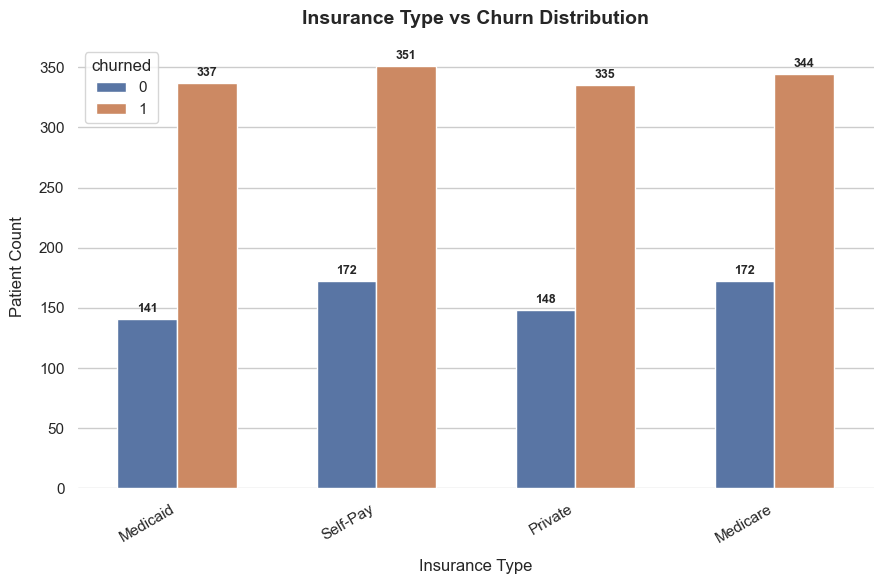

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(9, 6))

# Plot counts with a clean palette
ax = sns.countplot(data=df, x='insurance_type', hue='churned', palette=['#4c72b0', '#dd8452'], width=0.6)

# Add data labels above bars
for container in ax.containers:
    ax.bar_label(container, fontsize=9, padding=3, fontweight='semibold')

# Styling
ax.set_title("Insurance Type vs Churn Distribution", fontsize=14, fontweight='semibold', pad=15)
ax.set_xlabel("Insurance Type", fontsize=12, labelpad=10)
ax.set_ylabel("Patient Count", fontsize=12, labelpad=10)

# Rotate labels slightly so they don't overlap
plt.xticks(rotation=30, ha='right')

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

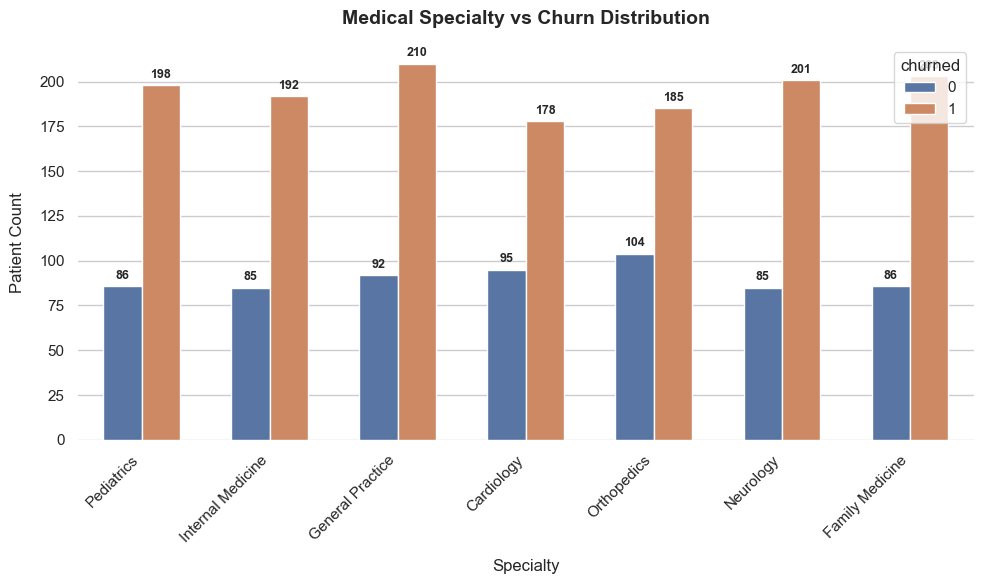

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))

ax = sns.countplot(data=df, x='specialty', hue='churned', palette=['#4c72b0', '#dd8452'], width=0.6)

for container in ax.containers:
    ax.bar_label(container, fontsize=9, padding=3, fontweight='semibold')

ax.set_title("Medical Specialty vs Churn Distribution", fontsize=14, fontweight='semibold', pad=15)
ax.set_xlabel("Specialty", fontsize=12, labelpad=10)
ax.set_ylabel("Patient Count", fontsize=12, labelpad=10)

# 45 degrees with right alignment prevents text overlap
plt.xticks(rotation=45, ha='right')

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

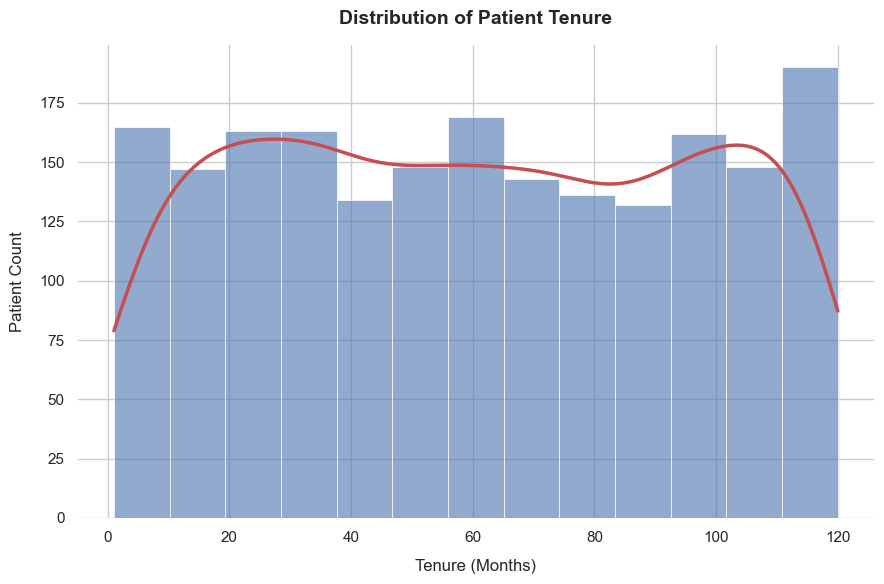

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(9, 6))

# Plot histogram with soft edges and a prominent KDE line
sns.histplot(
    data=df, 
    x='tenure_months', 
    kde=True, 
    color='#4c72b0', 
    alpha=0.6, 
    linewidth=0.5,
    edgecolor='white'
)

# Customize the line color directly if needed
ax.lines[0].set_color('#c44e52')
ax.lines[0].set_linewidth(2.5)

# Styling
ax.set_title("Distribution of Patient Tenure", fontsize=14, fontweight='semibold', pad=15)
ax.set_xlabel("Tenure (Months)", fontsize=12, labelpad=10)
ax.set_ylabel("Patient Count", fontsize=12, labelpad=10)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

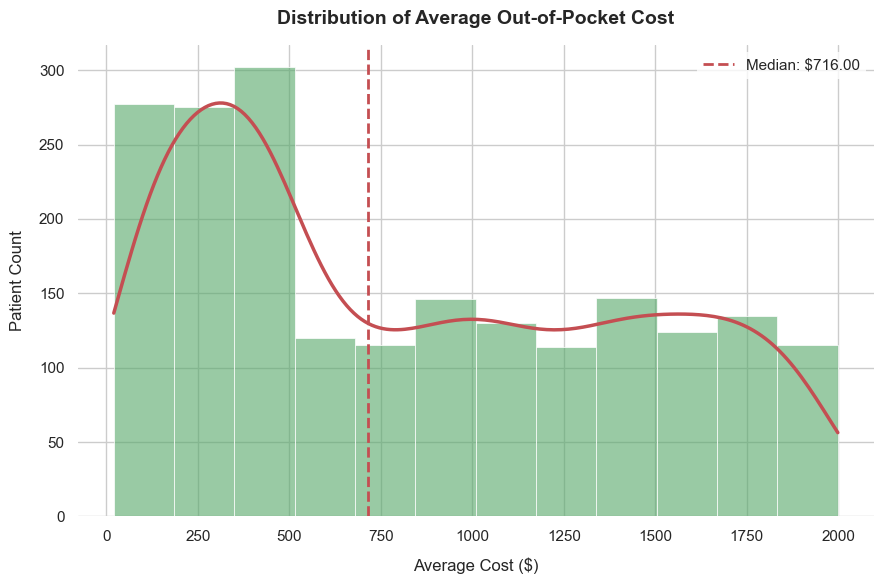

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(9, 6))

# Plot the distribution
sns.histplot(
    data=df, 
    x='avg_out_of_pocket_cost', 
    kde=True, 
    color='#55a868', 
    alpha=0.6, 
    edgecolor='white',
    linewidth=0.5
)

# Style the KDE line
if ax.lines:
    ax.lines[0].set_color('#c44e52')
    ax.lines[0].set_linewidth(2.5)

# Add a dashed line for the median cost
median_cost = df['avg_out_of_pocket_cost'].median()
ax.axvline(median_cost, color='#c44e52', linestyle='--', linewidth=2, label=f'Median: ${median_cost:,.2f}')
ax.legend(frameon=True, facecolor='white', edgecolor='none')

# Labels and Titles
ax.set_title("Distribution of Average Out-of-Pocket Cost", fontsize=14, fontweight='semibold', pad=15)
ax.set_xlabel("Average Cost ($)", fontsize=12, labelpad=10)
ax.set_ylabel("Patient Count", fontsize=12, labelpad=10)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

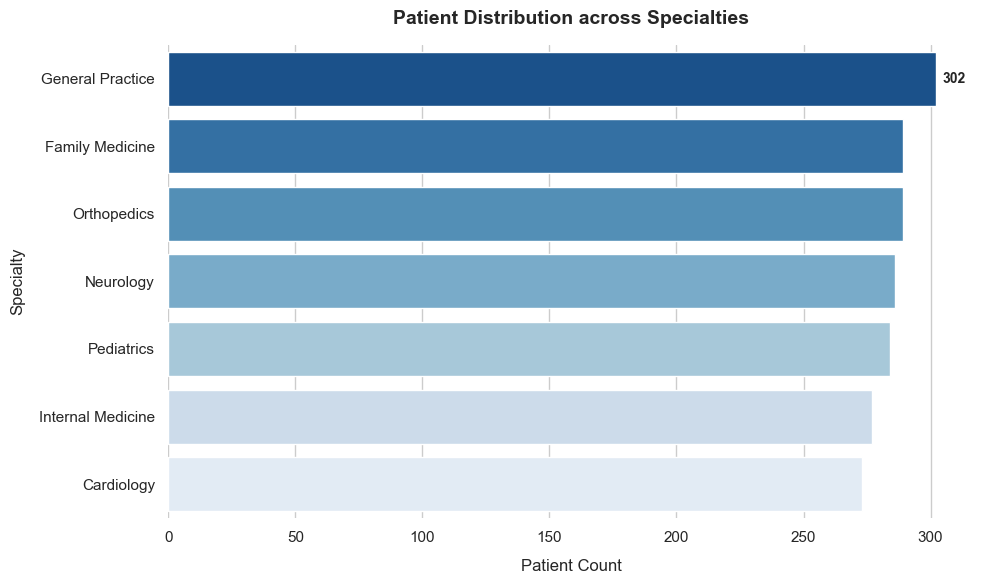

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))

# Get value counts as a structured dataframe for seaborn
specialty_counts = df['specialty'].value_counts().reset_index()
specialty_counts.columns = ['specialty', 'count']

# Plot horizontal bars
ax = sns.barplot(
    data=specialty_counts, 
    y='specialty', 
    x='count', 
    palette='Blues_r', 
    hue='specialty', 
    legend=False
)

# Add data labels to the end of each bar
ax.bar_label(ax.containers[0], fontsize=10, padding=5, fontweight='semibold')

# Titles and Labels
ax.set_title("Patient Distribution across Specialties", fontsize=14, fontweight='semibold', pad=15)
ax.set_xlabel("Patient Count", fontsize=12, labelpad=10)
ax.set_ylabel("Specialty", fontsize=12, labelpad=10)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

In [42]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])
corr_matrix = numeric_df.corr() 

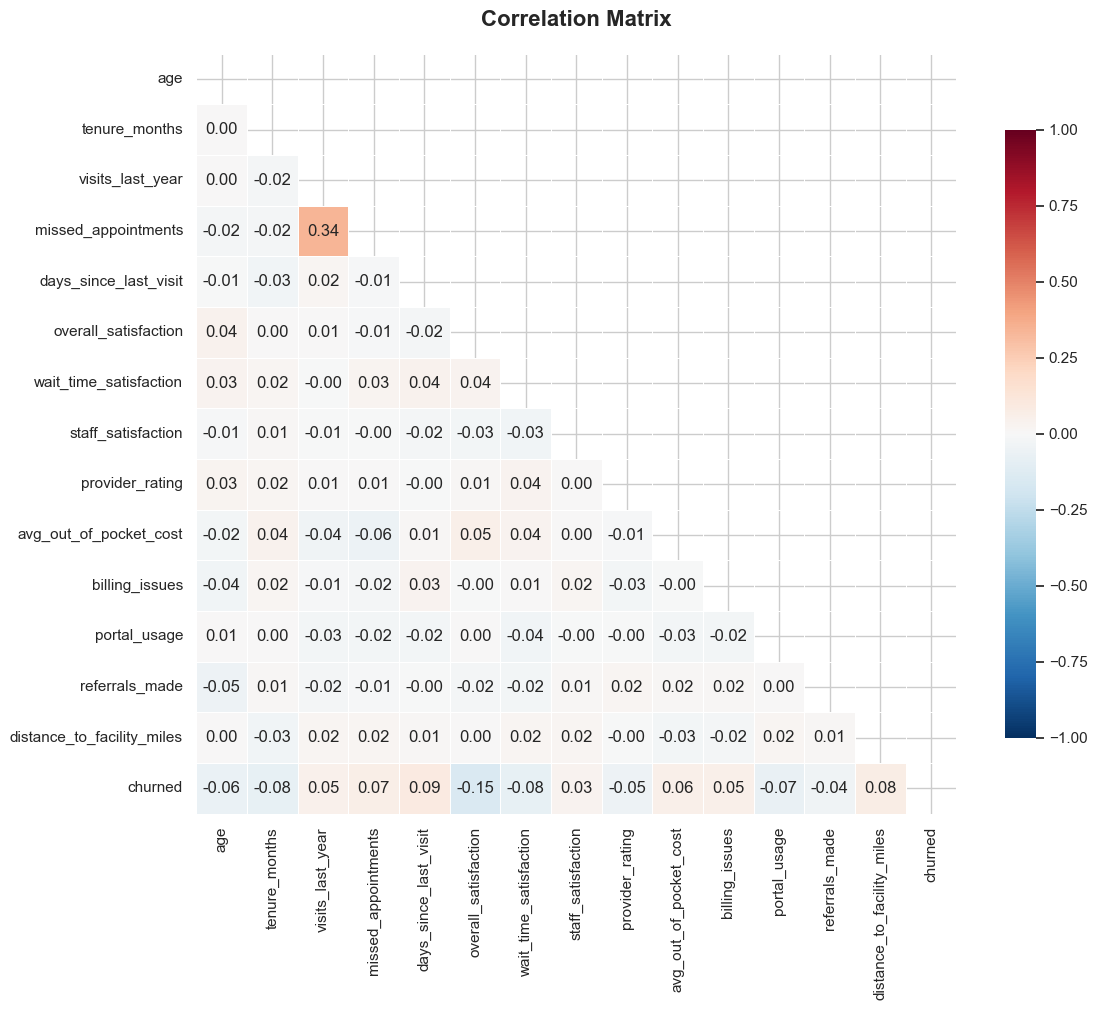

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(12, 10))

# Plot the heatmap
sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=True, 
    cmap='RdBu_r', 
    fmt=".2f", 
    vmin=-1, 
    vmax=1,
    square=True,
    linewidths=.5,
    cbar_kws={"shrink": .8}
)

plt.title("Correlation Matrix", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [44]:
df.drop(columns='patientid' , inplace =True)
df.drop(columns='last_interaction_date' , inplace =True)

Feature Engineering

In [45]:
df.head()

,age,gender,state,tenure_months,specialty,insurance_type,visits_last_year,missed_appointments,days_since_last_visit,overall_satisfaction,wait_time_satisfaction,staff_satisfaction,provider_rating,avg_out_of_pocket_cost,billing_issues,portal_usage,referrals_made,distance_to_facility_miles,churned
0,41,Female,PA,62,Pediatrics,Medicaid,1,0,564,3.5,4.9,3.8,4.2,306,0,0,3,21.4,1
1,43,Female,GA,44,Internal Medicine,Self-Pay,7,4,254,2.6,3.1,4.7,4.3,1851,0,0,0,47.6,1
2,21,Male,MI,120,Internal Medicine,Medicaid,15,5,89,1.6,4.4,2.1,4.7,391,0,0,2,7.1,0
3,65,Male,FL,118,General Practice,Private,10,3,135,2.6,4.3,4.3,4.9,808,0,0,0,11.6,1
4,18,Female,CA,70,Cardiology,Medicaid,5,4,696,2.2,4.0,4.1,4.4,866,0,0,0,10.3,1


In [46]:
from sklearn.preprocessing import LabelEncoder , StandardScaler
from sklearn.model_selection import train_test_split

Test Train Splits

In [47]:
X=df.drop('churned' , axis =1)
y=df['churned']

In [48]:
X_train , X_test , y_train , y_test = train_test_split(X,y, test_size=0.2 , random_state =42)

In [49]:
cols = X_train.select_dtypes(include=['object']).columns
cols

Index(['gender', 'state', 'specialty', 'insurance_type'], dtype='object')

In [50]:
from sklearn.preprocessing import OrdinalEncoder

# Instantiate once for all feature columns
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

# Pass the entire list of columns at once
X_train[cols] = encoder.fit_transform(X_train[cols])
X_test[cols] = encoder.transform(X_test[cols])

In [51]:
X_train.head()

,age,gender,state,tenure_months,specialty,insurance_type,visits_last_year,missed_appointments,days_since_last_visit,overall_satisfaction,wait_time_satisfaction,staff_satisfaction,provider_rating,avg_out_of_pocket_cost,billing_issues,portal_usage,referrals_made,distance_to_facility_miles
968,54,0.0,1.0,66,5.0,2.0,14,3,498,3.3,3.4,4.9,2.9,205,0,0,0,5.9
240,58,0.0,1.0,33,0.0,0.0,5,3,612,1.7,4.6,2.3,3.3,1733,0,0,3,8.8
819,57,0.0,1.0,61,4.0,2.0,12,4,583,3.5,4.6,4.2,4.4,1683,0,0,3,6.2
692,37,1.0,0.0,88,1.0,3.0,1,0,184,3.1,4.3,3.1,3.7,707,0,0,2,43.8
420,65,0.0,1.0,103,5.0,0.0,9,0,386,4.9,1.7,4.6,4.6,1927,0,0,0,19.1


In [52]:
scaler = StandardScaler()
features = ['tenure_months','visits_last_year','days_since_last_visit','avg_out_of_pocket_cost','distance_to_facility_miles']
X_train[features] = scaler.fit_transform(X_train[features])
X_test[features] = scaler.transform(X_test[features])

In [53]:
y.value_counts()

churned
1    1367
0     633
Name: count, dtype: int64

Model

In [59]:
from imblearn.over_sampling import SMOTE

# Synthesize minority class data to balance the training set
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"Original training shape: {X_train.shape}")
print(f"Balanced training shape: {X_train_balanced.shape}")

Original training shape: (1600, 18)
Balanced training shape: (2146, 18)


[LightGBM] [Info] Number of positive: 1073, number of negative: 1073
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000609 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3227
[LightGBM] [Info] Number of data points in the train set: 2146, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

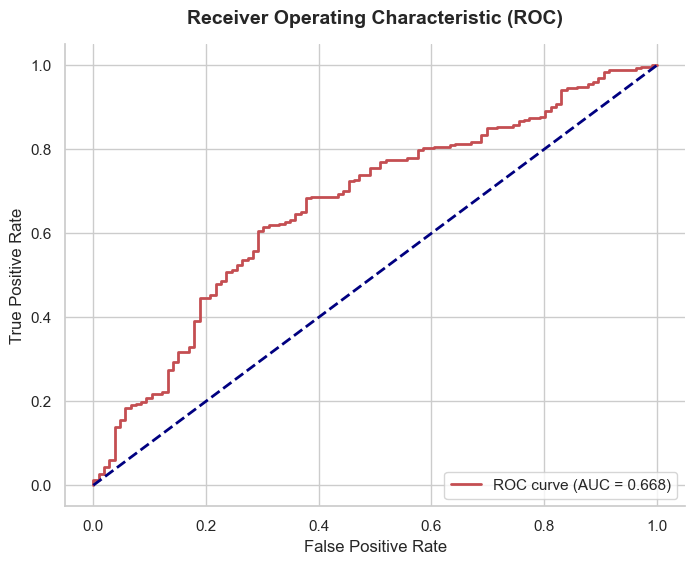

Classification Report:
              precision    recall  f1-score   support

           0       0.38      0.31      0.34       106
           1       0.77      0.82      0.79       294

    accuracy                           0.68       400
   macro avg       0.57      0.56      0.57       400
weighted avg       0.66      0.68      0.67       400



In [60]:
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, roc_curve, auc

# LightGBM handles large data faster and uses leaf-wise tree growth
model = lgb.LGBMClassifier(n_estimators=200, learning_rate=0.05, max_depth=7, random_state=42)
model.fit(X_train_balanced, y_train_balanced)

y_pred_prob = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#c44e52', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC)', fontsize=14, fontweight='bold', pad=15)
plt.legend(loc="lower right")
plt.gca().spines[['top', 'right']].set_visible(False)
plt.show()

print("Classification Report:")
print(classification_report(y_test, y_pred))

C:\Users\vshar\AppData\Roaming\Python\Python313\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


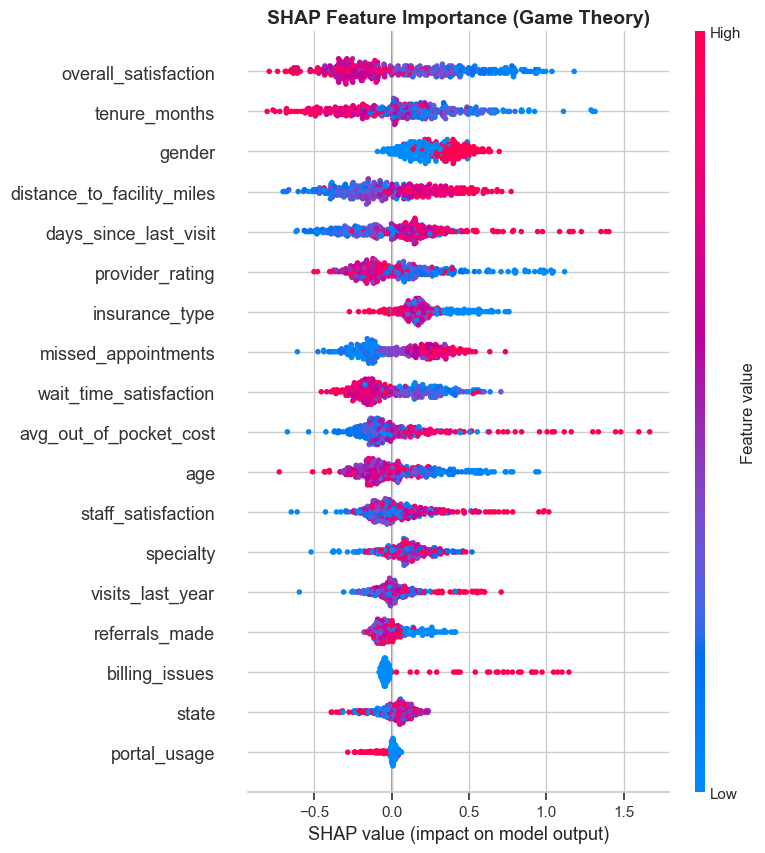

In [63]:
import shap

# Calculate SHAP values based on game theory
explainer = shap.TreeExplainer(model)

# LightGBM binary classification returns a list of SHAP values, we need the ones for class 1 (Churn)
shap_values = explainer.shap_values(X_test)
if isinstance(shap_values, list):
    shap_values = shap_values[1]

# Plot the summary beeswarm plot
plt.figure(figsize=(10, 8))
plt.title("SHAP Feature Importance (Game Theory)", fontsize=14, fontweight='bold')
shap.summary_plot(shap_values, X_test, plot_type="dot", show=False)
plt.tight_layout()
plt.show()

# ***Insights on Patient Churn Analysis***
## Based on the analysis of the features affecting patient churn, we have derived the following strategic insights:
- ### Missed Appointments:
The frequency of missed appointments is the strongest predictor of churn. A high number of "No-shows" is an early warning sign that a patient has mentally disengaged and is highly likely to switch providers.

- ## Wait Time Satisfaction:
Patient satisfaction regarding wait times is a critical factor for retention. Facilities that struggle with long wait times see a sharp increase in churn, as patients prioritize efficiency and time management in their healthcare experience.

- ## Out-of-Pocket Costs:
High average out-of-pocket costs significantly drive patients away. Patients are highly sensitive to expenses not covered by insurance, and reducing financial friction is key to maintaining a loyal patient base.

- ## Portal Usage:
Digital engagement through the patient portal is essential for loyalty. Patients who actively use the portal for scheduling and records tend to stay longer, as it creates a seamless and "sticky" experience with the facility.

- ## Billing Issues:
The presence of recurring billing issues acts as a major deterrent. Streamlining the billing process and eliminating errors can significantly increase trust and reduce the likelihood of a patient seeking an alternative provider.

- ## Distance to Facility:
The geographical distance plays a major role in the "convenience factor." Patients living further away from the facility are more prone to churn, especially when faced with minor service dissatisfactions.

- ## Staff and Provider Ratings:
High ratings for both medical providers and administrative staff are vital for keeping patients. While a good doctor is essential, poor interactions with the support staff can negate clinical satisfaction and lead to churn.

- ## Tenure (Relationship Length):
Patients in the early stages of their relationship with the facility (low tenure) are at the highest risk. Focus should be placed on the "onboarding" phase to ensure long-term commitment.